In [2]:
import xarray as xr
import xgcm
from typing import Annotated

In [3]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from xhistogram.xarray import histogram
import matplotlib.colors as colors
import cartopy.crs as ccrs
import scipy
import matplotlib.patches as patches

In [4]:
def open_llc4320_velocity_data(chunks='auto', time_range=None):
    
    ds_SSU = xr.open_dataset(
        "gs://pangeo-ecco-llc4320/ssu", 
        engine="zarr", 
        storage_options={'requester_pays': True}, 
        chunks=chunks, 
        inline_array=True,
        consolidated=True, 
    )
    
    ds_SSV = xr.open_dataset(
        "gs://pangeo-ecco-llc4320/ssv", 
        engine="zarr", 
        storage_options={'requester_pays': True}, 
        chunks=chunks, 
        inline_array=True,
        consolidated=True, 
    )
    
    # Open grid data
    ds_grid = xr.open_dataset(
        "gs://pangeo-ecco-llc4320/grid", 
        engine="zarr", 
        storage_options={'requester_pays': True}, 
        chunks=chunks, 
        inline_array=True,
        consolidated=True, 
    )
    
    coords_to_keep = ['XC', 'YC', 'dxC', 'dyC', 'dxG', 'dyG', 'rAz', 'rA', 'Depth']
    ds_grid = ds_grid.reset_coords()[coords_to_keep]
    
    ds = xr.merge([ds_SSU, ds_SSV, ds_grid])
    
    if time_range is not None:
        ds = ds.isel(time=time_range)
        
    ds = ds.chunk(chunks)
    
    return ds, ds_grid
    

In [5]:
ds, ds_grid = open_llc4320_velocity_data(chunks={})

In [6]:
grid = xgcm.Grid(ds_grid, periodic=False)

In [7]:



@xgcm.as_grid_ufunc(
    boundary_width={"X": (1, 0), "Y": (1, 0)},
    boundary="fill",
    fill_value=np.nan,
    dask="parallelized",    
)
def vort(
    u:   Annotated[np.ndarray, "(Y:center,X:left)"],
    dxc: Annotated[np.ndarray, "(Y:center,X:left)"],
    v:   Annotated[np.ndarray, "(Y:left,X:center)"],
    dyc: Annotated[np.ndarray, "(Y:left,X:center)"],
    raz: Annotated[np.ndarray, "(Y:left,X:left)"],
) ->     Annotated[np.ndarray, "(Y:left,X:left)"]:
    """Dimensional vorticity"""
    
    u_trans = u * dxc
    v_trans = v * dyc
    v_diff_x = v_trans[..., 1:, 1:] - v_trans[..., 1:, :-1]
    u_diff_y = u_trans[..., 1:, 1:] - u_trans[..., :-1, 1:]
    return (v_diff_x - u_diff_y) / raz[..., 1:, 1:]

@xgcm.as_grid_ufunc(
    boundary_width={"X": (1, 0), "Y": (1, 0)},
    boundary="fill",
    fill_value=np.nan,
    dask="parallelized",    
)
def strain(
    u:   Annotated[np.ndarray, "(Y:center,X:left)"],
    dxc: Annotated[np.ndarray, "(Y:center,X:left)"],
    v:   Annotated[np.ndarray, "(Y:left,X:center)"],
    dyc: Annotated[np.ndarray, "(Y:left,X:center)"],
) ->     Annotated[np.ndarray, "(Y:left,X:left)"]:
    u_diff_x = (u[..., 1:] - u[..., :-1]) / dxc[..., 1:]
    v_diff_x = (v[..., 1:] - v[..., :-1]) / dxc[..., 1:]
    u_diff_y = (u[..., 1:, :] - u[..., :-1, :]) / dyc[..., 1:, :]
    v_diff_y = (v[..., 1:, :] - v[..., :-1, :]) / dyc[..., 1:, :]
    
    u_diff_x_trimmed = u_diff_x[..., 1:, :]
    v_diff_x_trimmed = v_diff_x[..., 1:, :]
    u_diff_y_trimmed = u_diff_y[..., 1:]
    v_diff_y_trimmed = v_diff_y[..., 1:]
    
    strain_normal = u_diff_x_trimmed - v_diff_y_trimmed
    strain_shear = v_diff_x_trimmed + u_diff_y_trimmed
    
    # TODO: interpolate the shear strain onto the positions of the normal strain
    # For now, we just pretend they are at the same grid point
    strain_mag = np.sqrt(strain_normal ** 2 +  strain_shear ** 2)
    
    return strain_mag

@xgcm.as_grid_ufunc(
    boundary_width={"X": (1, 0), "Y": (1, 0)},
    boundary="fill",
    fill_value=np.nan,
    dask="parallelized",
)
def divergence(
    u:   Annotated[np.ndarray, "(Y:center,X:left)"],
    dxg: Annotated[np.ndarray, "(Y:left,X:center)"],
    v:   Annotated[np.ndarray, "(Y:left,X:center)"],
    dyg: Annotated[np.ndarray, "(Y:center,X:left)"],
    ra:  Annotated[np.ndarray, "(Y:center,X:center)"],
) ->     Annotated[np.ndarray, "(Y:center,X:center)"]:
    
    u_diff_x = (u[..., 1:] - u[..., :-1]) * dxg[..., 1:]
    v_diff_y = (v[..., 1:, :] - v[..., :-1, :]) * dyg[..., 1:, :]
    
    u_diff_x_trimmed = u_diff_x[..., 1:, :]
    v_diff_y_trimmed = v_diff_y[..., 1:]
    
    divergence = (u_diff_x_trimmed + v_diff_y_trimmed) / ra[..., 1:, 1:]
    
    return divergence

In [8]:
def vort_strain_div_bins(n_strain_bins=100, n_vort_bins=200, n_div_bins=200, vort_max=5, strain_max=5, div_max=5):
    vort_bins = np.linspace(-vort_max, vort_max, n_vort_bins)
    strain_bins = np.linspace(0.0, strain_max, n_strain_bins)
    div_bins = np.linspace(-div_max, div_max, n_div_bins)
    return vort_bins, strain_bins, div_bins

In [9]:
vort_bins, strain_bins, div_bins = vort_strain_div_bins(n_strain_bins=50, n_vort_bins=100, n_div_bins=100)
a = np.diff(vort_bins)[0]*np.diff(strain_bins)[0]*np.diff(div_bins)[0]

In [10]:
ζ = vort(grid, ds.U, ds.dxC, ds.V, ds.dyC, ds.rAz, axis= 5 * [("Y", "X")])
σ = strain(grid, ds.U, ds.dxC, ds.V, ds.dyC, axis=4 * [("Y", "X")])
D = divergence(grid, ds.U, ds.dxG, ds.V, ds.dyG, ds.rA, axis= 5 * [("Y", "X")])

/srv/conda/envs/notebook/lib/python3.12/site-packages/xgcm/grid_ufunc.py:832: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  out_dim: grid._ds.dims[out_dim] for arg in out_core_dims for out_dim in arg
/srv/conda/envs/notebook/lib/python3.12/site-packages/xgcm/grid_ufunc.py:832: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  out_dim: grid._ds.dims[out_dim] for arg in out_core_dims for out_dim in arg
/srv/conda/envs/notebook/lib/python3.12/site-packages/xgcm/grid_ufunc.py:832: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in orde

In [11]:
ds.sel(face=4).isel(i_g=slice(550,1100)).isel(i=slice(550,1100)).isel(j_g=slice(550,1100),j=slice(550,1100)).YC.max().values

array(-43.252, dtype=float32)

/tmp/ipykernel_86/2510200718.py:34: RuntimeWarning: invalid value encountered in divide
  u_diff_x = (u[..., 1:] - u[..., :-1]) / dxc[..., 1:]
/tmp/ipykernel_86/2510200718.py:35: RuntimeWarning: invalid value encountered in divide
  v_diff_x = (v[..., 1:] - v[..., :-1]) / dxc[..., 1:]
/tmp/ipykernel_86/2510200718.py:36: RuntimeWarning: invalid value encountered in divide
  u_diff_y = (u[..., 1:, :] - u[..., :-1, :]) / dyc[..., 1:, :]
/tmp/ipykernel_86/2510200718.py:37: RuntimeWarning: invalid value encountered in divide
  v_diff_y = (v[..., 1:, :] - v[..., :-1, :]) / dyc[..., 1:, :]


In [12]:
time_spec = 4000
σ_piece = σ.isel(time=time_spec).sel(face=4).isel(i_g=slice(550,1100)).isel(j_g=slice(0,550)).rename({"i_g": "i", "j_g": "j"})/10**-4
ζ_piece = ζ.isel(time=time_spec).sel(face=4).isel(i_g=slice(550,1100)).isel(j_g=slice(0,550)).rename({"i_g": "i", "j_g": "j"})/(-10**-4)
D_piece = D.isel(time=time_spec).sel(face=4).isel(i=slice(550,1100)).isel(j=slice(0,550))/10**-4

In [16]:
7*24

168

In [17]:
ds.isel(time=np.arange(time_spec-168,time_spec+168,3)).time

<xarray.DataArray 'time' (time: 112)> Size: 896B
array(['2012-02-19T16:00:00.000000000', '2012-02-19T19:00:00.000000000',
       '2012-02-19T22:00:00.000000000', '2012-02-20T01:00:00.000000000',
       '2012-02-20T04:00:00.000000000', '2012-02-20T07:00:00.000000000',
       '2012-02-20T10:00:00.000000000', '2012-02-20T13:00:00.000000000',
       '2012-02-20T16:00:00.000000000', '2012-02-20T19:00:00.000000000',
       '2012-02-20T22:00:00.000000000', '2012-02-21T01:00:00.000000000',
       '2012-02-21T04:00:00.000000000', '2012-02-21T07:00:00.000000000',
       '2012-02-21T10:00:00.000000000', '2012-02-21T13:00:00.000000000',
       '2012-02-21T16:00:00.000000000', '2012-02-21T19:00:00.000000000',
       '2012-02-21T22:00:00.000000000', '2012-02-22T01:00:00.000000000',
       '2012-02-22T04:00:00.000000000', '2012-02-22T07:00:00.000000000',
       '2012-02-22T10:00:00.000000000', '2012-02-22T13:00:00.000000000',
       '2012-02-22T16:00:00.000000000', '2012-02-22T19:00:00.000000000',
       '2012-02-22T22:00:00.000000000', '2012-02-23T01:00:00.000000000',
       '2012-02-23T04:00:00.000000000', '2012-02-23T07:00:00.000000000',
       '2012-02-23T10:00:00.000000000', '2012-02-23T13:00:00.000000000',
       '2012-02-23T16:00:00.000000000', '2012-02-23T19:00:00.000000000',
       '2012-02-23T22:00:00.000000000', '2012-02-24T01:00:00.000000000',
       '2012-02-24T04:00:00.000000000', '2012-02-24T07:00:00.000000000',
       '2012-02-24T10:00:00.000000000', '2012-02-24T13:00:00.000000000',
       '2012-02-24T16:00:00.000000000', '2012-02-24T19:00:00.000000000',
       '2012-02-24T22:00:00.000000000', '2012-02-25T01:00:00.000000000',
       '2012-02-25T04:00:00.000000000', '2012-02-25T07:00:00.000000000',
       '2012-02-25T10:00:00.000000000', '2012-02-25T13:00:00.000000000',
       '2012-02-25T16:00:00.000000000', '2012-02-25T19:00:00.000000000',
       '2012-02-25T22:00:00.000000000', '2012-02-26T01:00:00.000000000',
       '2012-02-26T04:00:00.000000000', '2012-02-26T07:00:00.000000000',
       '2012-02-26T10:00:00.000000000', '2012-02-26T13:00:00.000000000',
       '2012-02-26T16:00:00.000000000', '2012-02-26T19:00:00.000000000',
       '2012-02-26T22:00:00.000000000', '2012-02-27T01:00:00.000000000',
       '2012-02-27T04:00:00.000000000', '2012-02-27T07:00:00.000000000',
       '2012-02-27T10:00:00.000000000', '2012-02-27T13:00:00.000000000',
       '2012-02-27T16:00:00.000000000', '2012-02-27T19:00:00.000000000',
       '2012-02-27T22:00:00.000000000', '2012-02-28T01:00:00.000000000',
       '2012-02-28T04:00:00.000000000', '2012-02-28T07:00:00.000000000',
       '2012-02-28T10:00:00.000000000', '2012-02-28T13:00:00.000000000',
       '2012-02-28T16:00:00.000000000', '2012-02-28T19:00:00.000000000',
       '2012-02-28T22:00:00.000000000', '2012-02-29T01:00:00.000000000',
       '2012-02-29T04:00:00.000000000', '2012-02-29T07:00:00.000000000',
       '2012-02-29T10:00:00.000000000', '2012-02-29T13:00:00.000000000',
       '2012-02-29T16:00:00.000000000', '2012-02-29T19:00:00.000000000',
       '2012-02-29T22:00:00.000000000', '2012-03-01T01:00:00.000000000',
       '2012-03-01T04:00:00.000000000', '2012-03-01T07:00:00.000000000',
       '2012-03-01T10:00:00.000000000', '2012-03-01T13:00:00.000000000',
       '2012-03-01T16:00:00.000000000', '2012-03-01T19:00:00.000000000',
       '2012-03-01T22:00:00.000000000', '2012-03-02T01:00:00.000000000',
       '2012-03-02T04:00:00.000000000', '2012-03-02T07:00:00.000000000',
       '2012-03-02T10:00:00.000000000', '2012-03-02T13:00:00.000000000',
       '2012-03-02T16:00:00.000000000', '2012-03-02T19:00:00.000000000',
       '2012-03-02T22:00:00.000000000', '2012-03-03T01:00:00.000000000',
       '2012-03-03T04:00:00.000000000', '2012-03-03T07:00:00.000000000',
       '2012-03-03T10:00:00.000000000', '2012-03-03T13:00:00.000000000',
       '2012-03-03T16:00:00.000000000', '2012-03-03T19:00:00.000000000',
       '2012-03-03T22:00:00.000000000', '2012-03-04T01:00:00.000000000',
       '2

In [18]:
time_ran = 168
σ_piece2 = σ.isel(time=np.arange(time_spec-time_ran,time_spec+time_ran,3)).sel(face=4).isel(i_g=slice(550,1100)).isel(j_g=slice(0,550)).rename({"i_g": "i", "j_g": "j"})/10**-4
ζ_piece2 = ζ.isel(time=np.arange(time_spec-time_ran,time_spec+time_ran,3)).sel(face=4).isel(i_g=slice(550,1100)).isel(j_g=slice(0,550)).rename({"i_g": "i", "j_g": "j"})/(-10**-4)
D_piece2 = D.isel(time=np.arange(time_spec-time_ran,time_spec+time_ran,3)).sel(face=4).isel(i=slice(550,1100)).isel(j=slice(0,550))/10**-4


In [19]:
i_subregion = slice(400,550)
j_subregion = slice(300,450)

h = histogram(
    ζ_piece2.rename('vort').isel(i=i_subregion).isel(j=j_subregion),
    σ_piece2.rename('strain').isel(i=i_subregion).isel(j=j_subregion),
    D_piece2.rename('div').isel(i=i_subregion).isel(j=j_subregion),
    bins=[vort_bins, strain_bins, div_bins],
    block_size=None,  # avoids a divide-by-zero bug in xhistogram's code for automatically determining block_size
    density=False,  # setting this to true leads to an error right now
    keep_coords=True,
)
h = h/a/150/150#/550/550

In [20]:
def marginalize(pdf: xr.DataArray, dims: str | list = None) -> xr.DataArray:
    """
    Integrate out one or more dimensions of the PDF to remove dependence on that quantity,
    whilst still preserving the total integrated probability.
    """
       
    all_bin_dims = ['vort_bin', 'strain_bin', 'div_bin']
    
    if isinstance(dims, str):
        dims = [dims]
    
    if dims is None:
        dims=all_bin_dims
    
    if any(d not in all_bin_dims for d in dims):
        raise ValueError("Can't take marginal PDF over a dimension which is not a variable of the original PDF")
    
    marginal_pdf = pdf

    # TODO these might be more accurate if we used xarray's integrate function
    if 'vort_bin' in dims:
        vort_bin_width = pdf['vort_bin'].diff('vort_bin')[0]
        marginal_pdf = marginal_pdf.sum(dim='vort_bin') * vort_bin_width
        
    if 'strain_bin' in dims:
        strain_bin_width = pdf['strain_bin'].diff('strain_bin')[0]
        marginal_pdf = marginal_pdf.sum(dim='strain_bin') * strain_bin_width
        
    if 'div_bin' in dims:
        div_bin_width = pdf['div_bin'].diff('div_bin')[0]
        marginal_pdf = marginal_pdf.sum(dim='div_bin') * div_bin_width
        
    return marginal_pdf

def expectation(pdf: xr.DataArray, x: xr.DataArray, dims: str | list = None) -> xr.DataArray:
    """
    Take the expectation value of x over the given Probability Density Function.
    """
    
    return marginalize(pdf * x, dims=dims)

In [21]:
@xr.register_dataarray_accessor("pdf")
class DataArrayPDFAccessor:
    def __init__(self, da: xr.DataArray):
        self._da = da
        
    def marginalize(self, dims: str | list = None) -> xr.DataArray:
        return marginalize(self._da, dims=dims)
    
    def expectation(self, x, dims: str | list = None) -> xr.DataArray:
        return expectation(self._da, x, dims=dims)

In [22]:
h_vort_strain = (h.pdf.marginalize('div_bin')/97).load()
h_DivPdf = (h*h.div_bin).mean('div_bin').load()
lat = ds.sel(face=1).YC.mean('i')
lon = ds.sel(face=1).XC.mean('j')

lon_piece = ds.sel(face=4).isel(i=slice(550,1100)).isel(j=slice(0,550)).XC.mean('j')
lat_piece = ds.sel(face=4).isel(i=slice(550,1100)).isel(j=slice(0,550)).YC.mean('i')

/tmp/ipykernel_86/2510200718.py:34: RuntimeWarning: invalid value encountered in divide
  u_diff_x = (u[..., 1:] - u[..., :-1]) / dxc[..., 1:]
/tmp/ipykernel_86/2510200718.py:35: RuntimeWarning: invalid value encountered in divide
  v_diff_x = (v[..., 1:] - v[..., :-1]) / dxc[..., 1:]
/tmp/ipykernel_86/2510200718.py:36: RuntimeWarning: invalid value encountered in divide
  u_diff_y = (u[..., 1:, :] - u[..., :-1, :]) / dyc[..., 1:, :]
/tmp/ipykernel_86/2510200718.py:37: RuntimeWarning: invalid value encountered in divide
  v_diff_y = (v[..., 1:, :] - v[..., :-1, :]) / dyc[..., 1:, :]
/tmp/ipykernel_86/2510200718.py:34: RuntimeWarning: invalid value encountered in divide
  u_diff_x = (u[..., 1:] - u[..., :-1]) / dxc[..., 1:]
/tmp/ipykernel_86/2510200718.py:35: RuntimeWarning: invalid value encountered in divide
  v_diff_x = (v[..., 1:] - v[..., :-1]) / dxc[..., 1:]
/tmp/ipykernel_86/2510200718.py:36: RuntimeWarning: invalid value encountered in divide
  u_diff_y = (u[..., 1:, :] - u[...,

In [23]:
Depth_piece = ds.sel(face=4).isel(i_g=slice(550,1100)).isel(i=slice(550,1100)).isel(j_g=slice(0,550),j=slice(0,550)).Depth

<>:7: SyntaxWarning: invalid escape sequence '\z'
<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\z'
<>:8: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_611/2683867470.py:7: SyntaxWarning: invalid escape sequence '\z'
  plt.xlabel('$\zeta/f_{floor}$')
/tmp/ipykernel_611/2683867470.py:8: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('$\sigma/f_{floor}$')


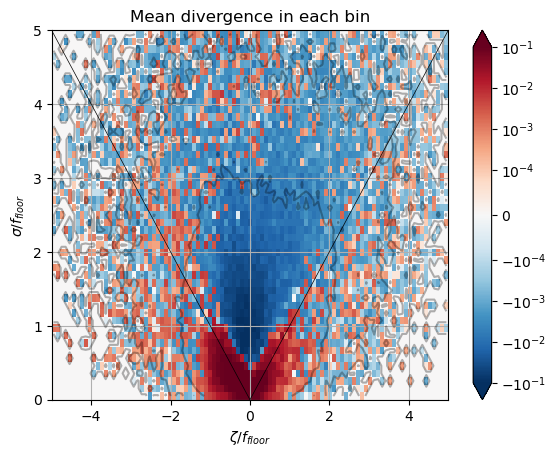

In [19]:
h_DivPdf.plot(x='vort_bin', vmax=0.1, norm=mpl.colors.SymLogNorm(1e-4))
h_vort_strain.plot.contour(x='vort_bin',levels=[1e-3, 1e-4, 1e-5], colors='k', alpha=.3)
plt.title('Mean divergence in each bin')
plt.plot(np.linspace(0,5), np.linspace(0,5),color='k',linewidth=0.5)
plt.plot(np.linspace(-5,0), np.linspace(5,0),color='k',linewidth=0.5)

plt.xlabel('$\zeta/f_{floor}$')
plt.ylabel('$\sigma/f_{floor}$')
plt.grid()

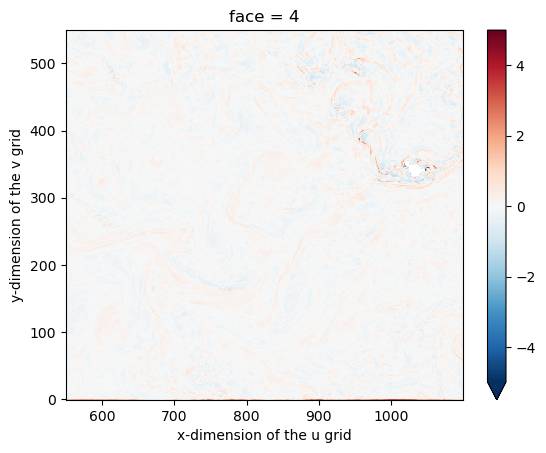

In [20]:
ζ_piece.plot(vmax=5)

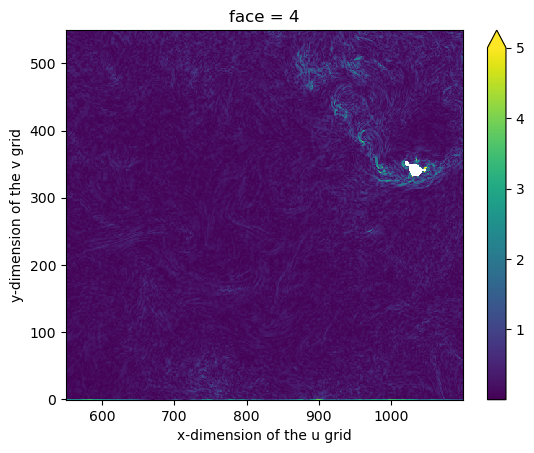

In [21]:
σ_piece.plot(vmax=5)

<>:23: SyntaxWarning: invalid escape sequence '\z'
<>:36: SyntaxWarning: invalid escape sequence '\z'
<>:37: SyntaxWarning: invalid escape sequence '\s'
<>:58: SyntaxWarning: invalid escape sequence '\s'
<>:23: SyntaxWarning: invalid escape sequence '\z'
<>:36: SyntaxWarning: invalid escape sequence '\z'
<>:37: SyntaxWarning: invalid escape sequence '\s'
<>:58: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_86/723724143.py:23: SyntaxWarning: invalid escape sequence '\z'
  plt.title('(b) $\zeta/f$ in example region')
/tmp/ipykernel_86/723724143.py:36: SyntaxWarning: invalid escape sequence '\z'
  plt.xlabel('$\zeta/f_{floor}$')
/tmp/ipykernel_86/723724143.py:37: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('$\sigma/f_{floor}$')
/tmp/ipykernel_86/723724143.py:58: SyntaxWarning: invalid escape sequence '\s'
  plt.title('(e) Divergence where $\sigma>3f$ \n & $\zeta<-3f$ (2 week mean)')


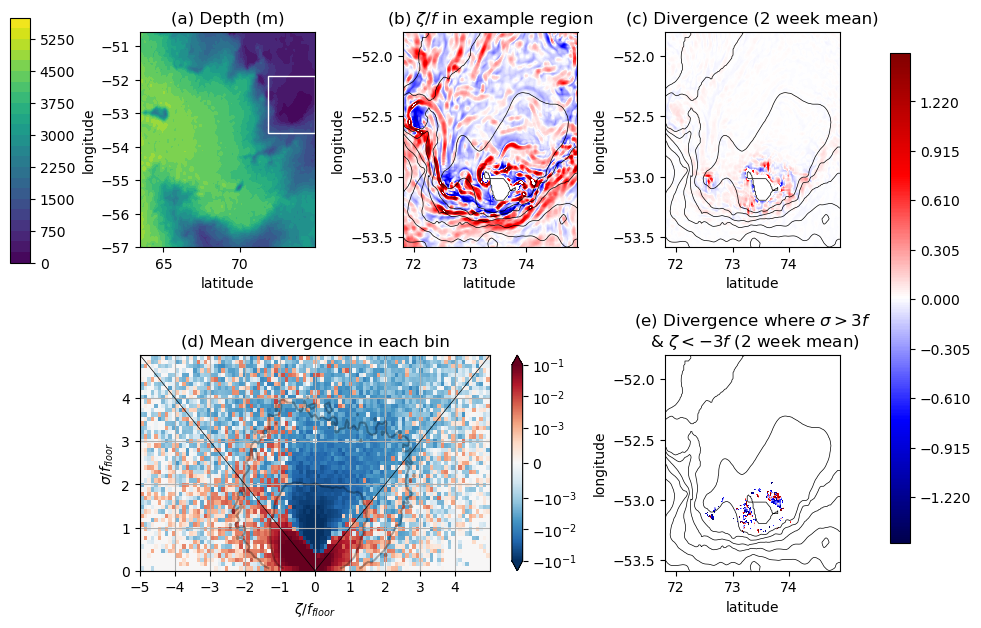

In [24]:
import matplotlib.patches as patches
fig3 = plt.figure(figsize=(10,7))
gs = fig3.add_gridspec(2, 3)



fig3.add_subplot(gs[0, 0])
cs1 = plt.contourf(lon_piece,lat_piece,Depth_piece.values, levels=np.arange(0,6000,250), cmap='viridis')
#plt.colorbar(cs1)
plt.title('(a) Depth (m)')
plt.xlabel('latitude')
plt.ylabel('longitude')
rect = patches.Rectangle((lon_piece.isel(i=400).values, lat_piece.isel(j=300).values), 3.1, 1.7, linewidth=1, edgecolor='w', facecolor='none')

# Add the patch to the Axes
plt.gca().add_patch(rect)

fig3.add_subplot(gs[0, 1])
plt.contourf(lon_piece.isel(i=i_subregion),lat_piece.isel(j=j_subregion),ζ_piece.isel(i=i_subregion).isel(j=j_subregion).values, levels=np.arange(-3,3.05,0.01)*0.5, cmap='seismic')
plt.contour(lon_piece.isel(i=i_subregion),lat_piece.isel(j=j_subregion),Depth_piece.isel(i=i_subregion).isel(j=j_subregion).values, levels=np.arange(0,6000,250),colors='k',linewidths=0.5)

#ζ_piece.plot(levels=np.arange(-1,1.05,0.01)*0.5)
plt.title('(b) $\zeta/f$ in example region')
plt.xlabel('latitude')
plt.ylabel('longitude')



fig3.add_subplot(gs[1, 0:2])
h_DivPdf.plot(x='vort_bin', vmax=0.1, norm=mpl.colors.SymLogNorm(1e-3))
h_vort_strain.plot.contour(x='vort_bin',levels=[1e-2, 1e-3], colors='k', alpha=.3)
plt.title('(d) Mean divergence in each bin')
plt.plot(np.linspace(0,5), np.linspace(0,5),color='k',linewidth=0.5)
plt.plot(np.linspace(-5,0), np.linspace(5,0),color='k',linewidth=0.5)

plt.xlabel('$\zeta/f_{floor}$')
plt.ylabel('$\sigma/f_{floor}$')
plt.grid()

x_ticks = np.arange(-5, 5)
y_ticks = np.arange(0, 5)

plt.gca().set_xticks(x_ticks)

plt.gca().set_yticks(y_ticks)


fig3.add_subplot(gs[0, 2])
plt.contourf(lon_piece.isel(i=i_subregion),lat_piece.isel(j=j_subregion),D_piece2.isel(i=i_subregion).isel(j=j_subregion).mean('time').values, levels=np.arange(-3,3.05,0.01)*0.5, cmap='bwr')
plt.contour(lon_piece.isel(i=i_subregion),lat_piece.isel(j=j_subregion),Depth_piece.isel(i=i_subregion).isel(j=j_subregion).values, levels=np.arange(0,6000,250),colors='k',linewidths=0.5)
plt.title('(c) Divergence (2 week mean)')
plt.xlabel('latitude')
plt.ylabel('longitude')

fig3.add_subplot(gs[1, 2])
cs = plt.contourf(lon_piece.isel(i=i_subregion),lat_piece.isel(j=j_subregion),D_piece2.isel(i=i_subregion).isel(j=j_subregion).where((σ_piece2>3) & (ζ_piece2<-3)).mean('time').values, levels=np.arange(-3,3.05,0.01)*0.5, cmap='seismic')
plt.contour(lon_piece.isel(i=i_subregion),lat_piece.isel(j=j_subregion),Depth_piece.isel(i=i_subregion).isel(j=j_subregion).values, levels=np.arange(0,6000,250),colors='k',linewidths=0.5)
plt.title('(e) Divergence where $\sigma>3f$ \n & $\zeta<-3f$ (2 week mean)')
plt.xlabel('latitude')
plt.ylabel('longitude')

plt.subplots_adjust(hspace=0.5, wspace=0.5,right=0.85,left=0.15)
cbar_ax = fig3.add_axes([0.9, 0.15, 0.02, 0.7])
fig3.colorbar(cs, cax=cbar_ax,extend='both')

cbar_ax = fig3.add_axes([0.02, 0.55, 0.02, 0.35])
fig3.colorbar(cs1, cax=cbar_ax)

plt.gcf().savefig('hi-strain-topog-kerg.png')
plt.show()